In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/quora/question-pairs-dataset/questions.csv


In [5]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/organizations/quora/question-pairs-dataset/questions.csv')

df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [6]:
# Keep only needed columns
df = df[['question1', 'question2', 'is_duplicate']]

# Remove null values
df = df.dropna()

# Reset index (clean structure)
df = df.reset_index(drop=True)

# Check basic info
print(df.shape)
df.head()

(404348, 3)


,question1,question2,is_duplicate
0,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Combine both questions into one text
df['combined_text'] = df['question1'] + " " + df['question2']

# Initialize TF-IDF
tfidf = TfidfVectorizer(max_features=5000)

# Fit and transform
X = tfidf.fit_transform(df['combined_text'])

# Target variable
y = df['is_duplicate']

print("Feature shape:", X.shape)

Feature shape: (404348, 5000)


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.7532088537158402

Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.86      0.82     51240
           1       0.70      0.57      0.63     29630

    accuracy                           0.75     80870
   macro avg       0.74      0.71      0.72     80870
weighted avg       0.75      0.75      0.75     80870



In [9]:
import numpy as np

def get_features(row):
    q1 = str(row['question1']).lower().split()
    q2 = str(row['question2']).lower().split()
    
    set_q1 = set(q1)
    set_q2 = set(q2)
    
    common_words = len(set_q1 & set_q2)
    total_words = len(set_q1 | set_q2)
    
    return pd.Series([
        len(q1),
        len(q2),
        abs(len(q1) - len(q2)),
        common_words,
        total_words,
        common_words / total_words if total_words != 0 else 0
    ])

df[['q1_len', 'q2_len', 'len_diff', 'common_words', 'total_words', 'word_share']] = df.apply(get_features, axis=1)

In [10]:
df.head()

,question1,question2,is_duplicate,combined_text,q1_len,q2_len,len_diff,common_words,total_words,word_share
0,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0,What is the step by step guide to invest in sh...,14.0,12.0,2.0,10.0,13.0,0.769231
1,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0,What is the story of Kohinoor (Koh-i-Noor) Dia...,8.0,13.0,5.0,4.0,16.0,0.250000
2,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0,How can I increase the speed of my internet co...,14.0,10.0,4.0,4.0,20.0,0.200000
3,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0,Why am I mentally very lonely? How can I solve...,11.0,9.0,2.0,0.0,19.0,0.000000
4,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0,"Which one dissolve in water quikly sugar, salt...",13.0,7.0,6.0,2.0,18.0,0.111111


In [11]:
from scipy.sparse import hstack

# Convert new features to array
extra_features = df[['q1_len', 'q2_len', 'len_diff', 'common_words', 'total_words', 'word_share']].values

# Combine with TF-IDF
X_combined = hstack((X, extra_features))

print("New feature shape:", X_combined.shape)

New feature shape: (404348, 5006)


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

# Split using combined features
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, random_state=42
)

# Train SVM
svm_model = LinearSVC()
svm_model.fit(X_train, y_train)

# Predictions
y_pred = svm_model.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.7826758995919377

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.85      0.83     51240
           1       0.72      0.67      0.69     29630

    accuracy                           0.78     80870
   macro avg       0.77      0.76      0.76     80870
weighted avg       0.78      0.78      0.78     80870



In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import hstack
import numpy as np

# 1. TF-IDF on individual questions (IMPORTANT)
tfidf = TfidfVectorizer(max_features=5000)

q1_tfidf = tfidf.fit_transform(df['question1'])
q2_tfidf = tfidf.transform(df['question2'])  # use same vocab

# 2. Efficient cosine similarity (row-wise)
cosine_sim = np.array([
    cosine_similarity(q1_tfidf[i], q2_tfidf[i])[0][0]
    for i in range(q1_tfidf.shape[0])
])

# Add to dataframe
df['cosine_sim'] = cosine_sim

print("Cosine similarity added")

Cosine similarity added


In [14]:
# Updated extra features
extra_features = df[['q1_len', 'q2_len', 'len_diff', 
                     'common_words', 'total_words', 
                     'word_share', 'cosine_sim']].values

# Combine everything
X_final = hstack((q1_tfidf, q2_tfidf, extra_features))

print("Final feature shape:", X_final.shape)

Final feature shape: (404348, 10007)


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42
)

# Initialize model
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Train
xgb_model.fit(X_train, y_train)

# Predict
y_pred = xgb_model.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:20:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.7702114504760728

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.79      0.81     51240
           1       0.67      0.74      0.70     29630

    accuracy                           0.77     80870
   macro avg       0.75      0.76      0.76     80870
weighted avg       0.78      0.77      0.77     80870



In [27]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier

lr = LogisticRegression(max_iter=2000, solver='saga')
svm = LinearSVC()

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss'
)

ensemble = VotingClassifier(
    estimators=[
        ('lr', lr),
        ('svm', svm),
        ('xgb', xgb)
    ],
    voting='hard'
)

In [29]:
ensemble.fit(X_train, y_train)
 
y_pred = ensemble.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Accuracy: 0.7813898850006182
              precision    recall  f1-score   support

           0       0.81      0.85      0.83     51240
           1       0.72      0.66      0.69     29630

    accuracy                           0.78     80870
   macro avg       0.77      0.76      0.76     80870
weighted avg       0.78      0.78      0.78     80870



In [30]:
X_lgb = X_final.astype('float32')

In [31]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, classification_report

lgb_model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgb_model.fit(X_train, y_train)

y_pred = lgb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

[LightGBM] [Info] Number of positive: 119676, number of negative: 203802
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 9.435738 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 365812
[LightGBM] [Info] Number of data points in the train set: 323478, number of used features: 5006
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.369966 -> initscore=-0.532361
[LightGBM] [Info] Start training from score -0.532361


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy: 0.806244590082849
              precision    recall  f1-score   support

           0       0.85      0.84      0.85     51240
           1       0.73      0.74      0.74     29630

    accuracy                           0.81     80870
   macro avg       0.79      0.79      0.79     80870
weighted avg       0.81      0.81      0.81     80870



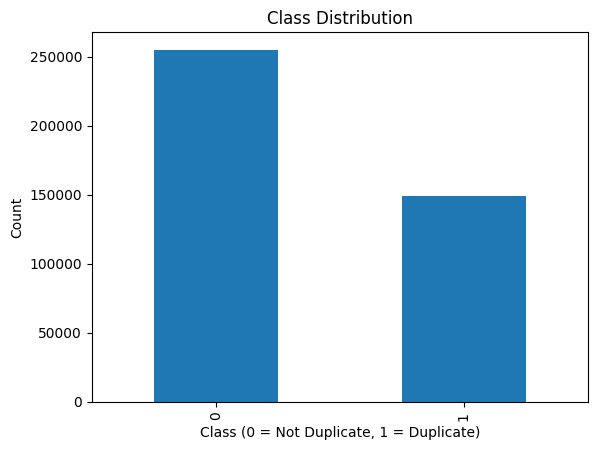

In [32]:
import matplotlib.pyplot as plt

df['is_duplicate'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Class (0 = Not Duplicate, 1 = Duplicate)")
plt.ylabel("Count")
plt.show()

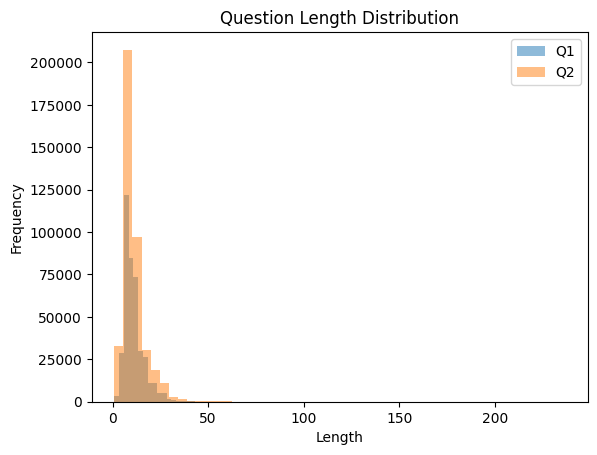

In [33]:
plt.hist(df['q1_len'], bins=50, alpha=0.5, label='Q1')
plt.hist(df['q2_len'], bins=50, alpha=0.5, label='Q2')
plt.title("Question Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.legend()
plt.show()

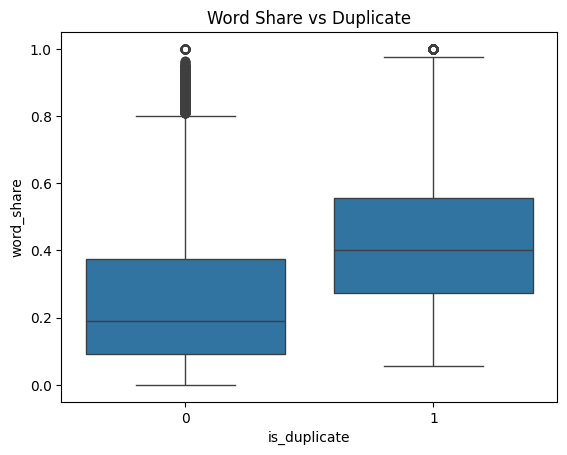

In [34]:
import seaborn as sns

sns.boxplot(x='is_duplicate', y='word_share', data=df)
plt.title("Word Share vs Duplicate")
plt.show()

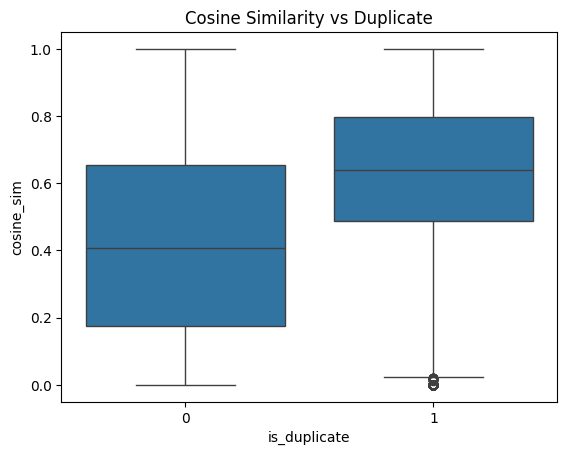

In [35]:
sns.boxplot(x='is_duplicate', y='cosine_sim', data=df)
plt.title("Cosine Similarity vs Duplicate")
plt.show()

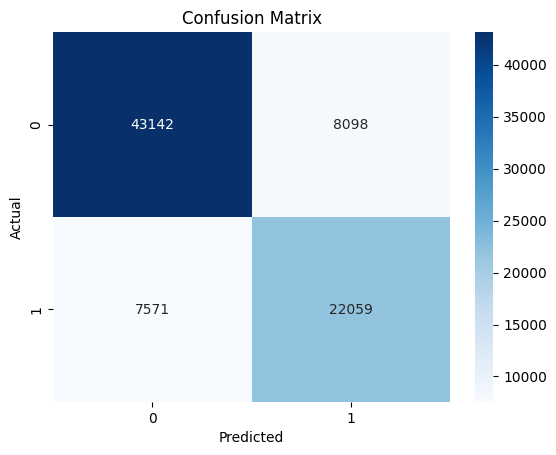

In [36]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

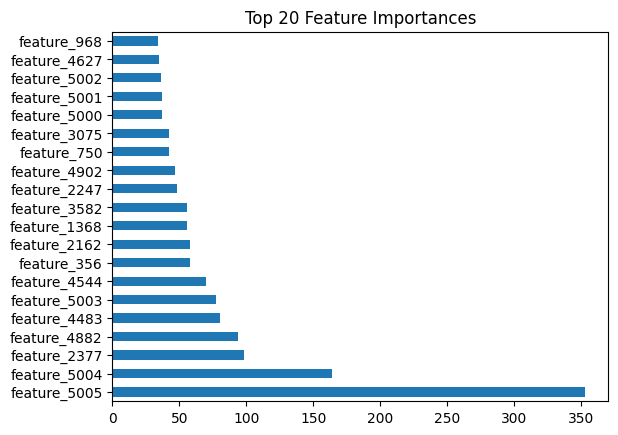

In [39]:
feature_names = [f"feature_{i}" for i in range(len(lgb_model.feature_importances_))]

import pandas as pd
import matplotlib.pyplot as plt

feat_imp = pd.Series(lgb_model.feature_importances_, index=feature_names)

feat_imp.nlargest(20).plot(kind='barh')
plt.title("Top 20 Feature Importances")
plt.show()

In [40]:
import pickle

with open('/kaggle/working/final_quora_lgbm_model.pkl', 'wb') as f:
    pickle.dump(lgb_model, f)

print("Model saved successfully!")

Model saved successfully!
